In [16]:
# Kiểm tra môi trường & phiên bản
import sys, subprocess

def pkg_version(name):
    try:
        mod = __import__(name)
        return getattr(mod, "__version__", "n/a")
    except Exception as e:
        return f"NOT INSTALLED ({e})"

print("Python:", sys.version)
for lib in ["sklearn", "matplotlib"]:
    print(f"{lib}:", pkg_version(lib))

Python: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)]
sklearn: 1.6.1
matplotlib: 3.10.0


## 1. Tải dữ liệu & chia tập

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import export_text

iris = load_iris()
x = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

def print_tree(x_train, x_test, y_train, y_test, feature_names, target_names):
    print("Kích thước tập train:", x_train.shape, " | test:", x_test.shape)
    print("Nhãn:", list(target_names))

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(x_train, y_train)


    # Sau khi clf.fit(...)
    tree_rules = export_text(clf, feature_names=feature_names)
    print(tree_rules)
    with open("tree_maxdepth4.txt", "w", encoding="utf-8") as f:
        f.write(tree_rules)

    y_pred = clf.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Độ chính xác (Accuracy): {acc:.4f}\n")
    print("Báo cáo phân loại:\n", classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:\n", cm)

    # plt.figure(figsize=(12, 8))
    # plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True, rounded=True)
    # plt.title("Decision Tree (max_depth=3) trên tập Iris")
    # plt.show()

## 2-3. Huấn luyện mô hình Decision Tree - Trực quan hoá cây quyết định

In [29]:
RANDOMSTATE = 32 # 42
step = 10

for index in range(4):
    print(f"\n\nRandom state: {RANDOMSTATE}")
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOMSTATE, stratify=y)
    print_tree(x_train, x_test, y_train, y_test, feature_names, target_names)
    RANDOMSTATE += step
    step += 3



Random state: 32
Kích thước tập train: (120, 4)  | test: (30, 4)
Nhãn: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2

Độ chính xác (Accuracy): 0.9667

Báo cáo phân loại:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


Random state: 42
Kích thước tập train: (120, 4)  | test: (30, 4)
Nhãn

## 4. Try yourself — Thay đổi siêu tham số

In [25]:
# Mục tiêu: quan sát thay đổi Accuracy và cấu trúc cây.
from sklearn.model_selection import train_test_split

def custom(index = 0):
    if index == 0:
        MAX_DEPTH = 4
        CRITERION = 'gini'      # hoặc 'entropy'
        SPLITTER = 'best'       # hoặc 'random'
        TEST_SIZE = 0.25        # 0.2, 0.3, ...
    elif index == 1:
        MAX_DEPTH = 10
        CRITERION = 'entropy'
        SPLITTER = 'random'
        TEST_SIZE = 0.25
    elif index == 2:
        MAX_DEPTH = 6
        CRITERION = 'entropy'
        SPLITTER = 'best'
        TEST_SIZE = 0.25
    elif index == 3:
        MAX_DEPTH = 8
        CRITERION = 'gini'
        SPLITTER = 'random'
        TEST_SIZE = 0.25

    RANDOMSTATE = 99 # 0

    x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size=TEST_SIZE, random_state=RANDOMSTATE, stratify=y)

    clf2 = DecisionTreeClassifier(max_depth=MAX_DEPTH, criterion=CRITERION, splitter=SPLITTER, random_state=RANDOMSTATE)
    clf2.fit(x_train2, y_train2)
    y_pred2 = clf2.predict(x_test2)

    print(f"\n\n[Thử nghiệm] max_depth={MAX_DEPTH}, criterion={CRITERION}, splitter={SPLITTER}, test_size={TEST_SIZE}")
    print("Accuracy:", accuracy_score(y_test2, y_pred2), "\n")
    
    # Print Tree
    tree_rules = export_text(clf2, feature_names=feature_names)
    print(tree_rules)

    # plt.figure(figsize=(12, 8))
    # plot_tree(clf2, feature_names=feature_names, class_names=target_names, filled=True, rounded=True)
    # plt.title(f"Decision Tree (max_depth={MAX_DEPTH}) — thử nghiệm")
    # plt.show()

index = 0

for i in range(4):
    custom(i)
    index += 1



[Thử nghiệm] max_depth=4, criterion=gini, splitter=best, test_size=0.25
Accuracy: 0.9736842105263158 

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



[Thử nghiệm] max_depth=10, criterion=entropy, splitter=random, test_size=0.25
Accuracy: 0.9473684210526315 

|--- petal width (cm)

## 5. Bài tập ngắn (5–10 phút)
1. Chạy lại phần "Try yourself" với 2 cấu hình khác nhau và ghi nhận Accuracy.
2. Thử thay đổi `random_state` ở bước chia tập để xem ảnh hưởng.
3. (Nâng cao) Thêm `GridSearchCV` để chọn `max_depth` tối ưu (gợi ý: `from sklearn.model_selection import GridSearchCV`).
4. Viết báo cáo bài tập, phân tích kết quả, các tham số thử nghiệm


=== Bảng kết quả CV cho từng max_depth ===
 param_max_depth  mean_train_score  mean_test_score  rank_test_score
               1          0.674107         0.651779                9
               2          0.970986         0.928458                8
               3          0.975456         0.937549                1
               4          0.993308         0.929249                2
               5          0.997778         0.929249                2
               6          1.000000         0.929249                2
               7          1.000000         0.929249                2
               8          1.000000         0.929249                2
               9          1.000000         0.929249                2

Best max_depth: 3
Best CV accuracy: 0.9375494071146244

=== Đánh giá trên tập test ===
Test Accuracy: 0.8947368421052632
Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolo

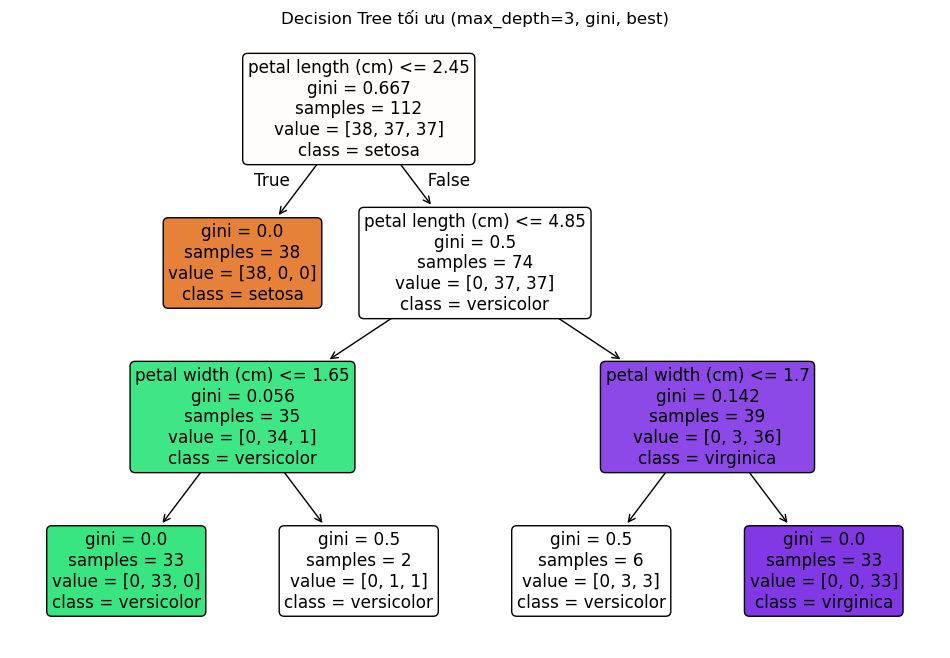

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 1. Tải dữ liệu
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Hàm chạy tìm max_depth tối ưu cho cấu hình cố định
def run_best_maxdepth(random_state):
    # Chia dữ liệu
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state, stratify=y
    )

    # Chỉ tìm max_depth, giữ criterion và splitter cố định
    param_grid = {
        'max_depth': list(range(1, 10)),
        'criterion': ['gini'],
        'splitter': ['best']
    }

    grid_search = GridSearchCV(
        DecisionTreeClassifier(random_state=random_state),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        return_train_score=True
    )
    grid_search.fit(X_train, y_train)

    # In bảng toàn bộ kết quả
    results_df = pd.DataFrame(grid_search.cv_results_)[
        ['param_max_depth', 'mean_train_score', 'mean_test_score', 'rank_test_score']
    ].sort_values('param_max_depth')
    print("\n=== Bảng kết quả CV cho từng max_depth ===")
    print(results_df.to_string(index=False))

    # Thông số tối ưu
    best_params = grid_search.best_params_
    print("\nBest max_depth:", best_params['max_depth'])
    print("Best CV accuracy:", grid_search.best_score_)

    # Huấn luyện với mô hình tối ưu
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Đánh giá trên tập test
    print("\n=== Đánh giá trên tập test ===")
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred, target_names=target_names))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    # Vẽ cây tối ưu
    plt.figure(figsize=(12, 8))
    plot_tree(best_model, feature_names=feature_names, class_names=target_names, filled=True, rounded=True)
    plt.title(f"Decision Tree tối ưu (max_depth={best_model.max_depth}, gini, best)")
    plt.show()

# 3. Chạy cho random_state=42
run_best_maxdepth(random_state=42)
